In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(["simulation"])

In [3]:
from CADETProcess.processModel import LumpedRateModelWithoutPores

zone_template = LumpedRateModelWithoutPores(
    component_system,
    "zone_template",
    total_porosity=0.7,
    length=2.2e-3,
    axial_dispersion=7e-9,
)

In [4]:
from CADETProcess.modelBuilder import ZRMFlowSheetBuilder

builder = ZRMFlowSheetBuilder(
    configuration="axial",
    zone_template=zone_template,
    segments_area=[11.66e-04, 10.34e-04],
    void_in_volumes=[1.69e-06, 1.24e-06],
    void_out_volumes=[1.69e-06, 1.24e-06],
)

flow_sheet = builder.build_flow_sheet()

In [5]:
from CADETProcess.processModel import Inlet, Outlet

inlet = Inlet(component_system, "inlet")

flow_rate = 1e-6    # m^3/s
inlet.c = [1]       # mM
inlet.flow_rate = flow_rate

outlet = Outlet(component_system, "outlet")

In [6]:
import math
from CADETProcess.processModel import TubularReactor

delay_time = 3.0       # s

delay_tube = TubularReactor(component_system, "delay_tube")
delay_tube.length = 0.1
delay_tube.diameter = math.sqrt(
    (delay_time * flow_rate / delay_tube.length) * 4 / math.pi
)
delay_tube.axial_dispersion = 0  # no dispersion

In [7]:
flow_sheet.add_unit(inlet)
flow_sheet.add_unit(delay_tube)
flow_sheet.add_unit(outlet)

flow_sheet.add_connection(inlet, delay_tube)
flow_sheet.add_connection(delay_tube, builder.inlet_port)
flow_sheet.add_connection(builder.outlet_port, outlet)

In [8]:
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet

simulator = Cadet()

process = Process(flow_sheet, "ZRM")
process.cycle_time = 50

results = simulator.simulate(process)

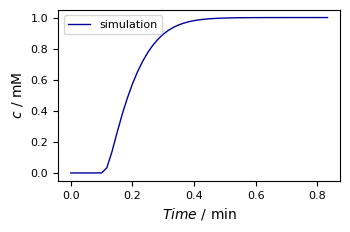

In [9]:
_ = results.solution.outlet.outlet.plot()

In [10]:
from CADETProcess.modelBuilder import ZRMFlowSheetBuilder

builder = ZRMFlowSheetBuilder(
    configuration="axial",
    zone_template=zone_template,
    segments_area=[22e-04],
    void_in_volumes=[2.93e-06],
    void_out_volumes=[2.93e-06],
)

flow_sheet = builder.build_flow_sheet()

_ = results.solution.outlet.outlet.plot()